In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Sentiment Dataset
df = pd.read_csv('3) Sentiment dataset.csv')

# Clean whitespace from column names
df.columns = df.columns.str.strip()

print("Dataset Loaded Successfully!")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
df.head()

Dataset Loaded Successfully!
Total Rows: 732 | Total Columns: 15


,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [3]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

# Auto-detect text column name
text_col = [c for c in df.columns if any(k in c.lower() for k in ['text', 'tweet', 'review', 'comment'])][0] if any(any(k in c.lower() for k in ['text', 'tweet', 'review', 'comment']) for c in df.columns) else df.select_dtypes(include=['object']).columns[0]

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    # Remove URLs, special characters, and numbers
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()

    # Tokenization
    tokens = word_tokenize(text)

    # Remove Stopwords & Lemmatize
    cleaned = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]
    return " ".join(cleaned)

df['cleaned_text'] = df[text_col].apply(preprocess_text)
print(f"Preprocessing completed on target column: '{text_col}'")
df[[text_col, 'cleaned_text']].head()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Preprocessing completed on target column: 'Text'


,Text,cleaned_text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight


In [5]:
from textblob import TextBlob

# Calculate Polarity Score (-1 to 1)
df['polarity'] = df['cleaned_text'].apply(lambda txt: TextBlob(txt).sentiment.polarity)

# Classify into Positive, Neutral, or Negative
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment'] = df['polarity'].apply(classify_sentiment)

print("Sentiment Counts:")
print(df['sentiment'].value_counts())

Sentiment Counts:
sentiment
Neutral     348
Positive    277
Negative    107
Name: count, dtype: int64


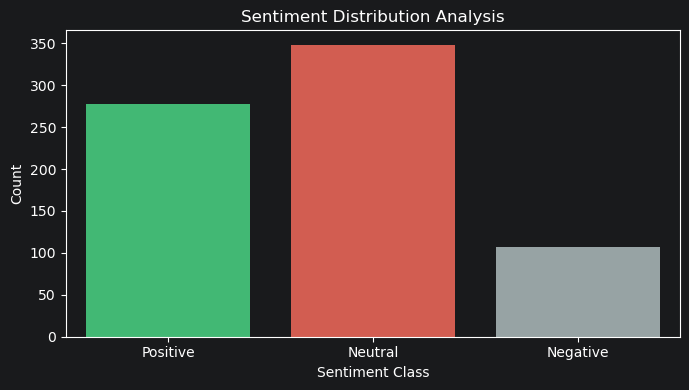

In [7]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df,
    x='sentiment',
    hue='sentiment',
    legend=False,
    order=['Positive', 'Neutral', 'Negative'],
    palette=['#2ecc71', '#95a5a6', '#e74c3c']
)
plt.title('Sentiment Distribution Analysis')
plt.xlabel('Sentiment Class')
plt.ylabel('Count')
plt.tight_layout()

# Save visual asset for repo
plt.savefig('sentiment_distribution.png')
plt.show()

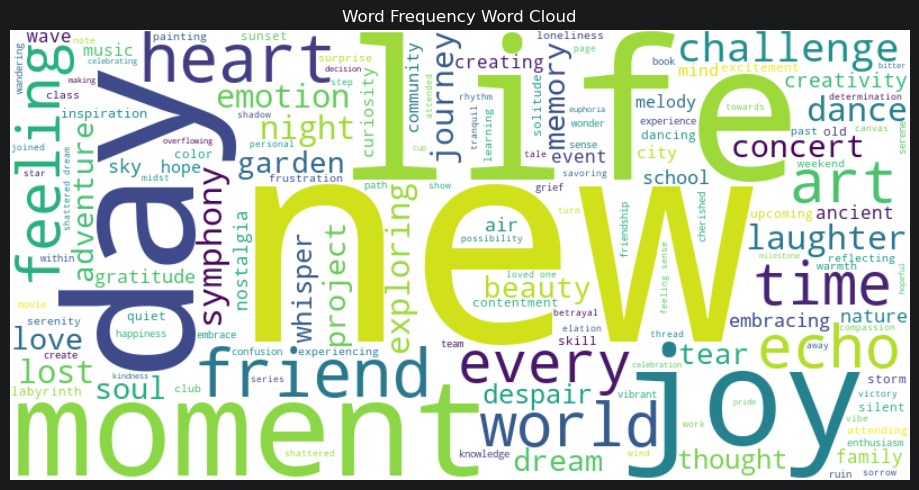

In [9]:
from wordcloud import WordCloud

# Combine cleaned text for Word Cloud generation
text_corpus = " ".join(df['cleaned_text'].dropna())

# Generate Word Cloud
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=150
).generate(text_corpus)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Frequency Word Cloud')
plt.tight_layout()

# Save Word Cloud asset
plt.savefig('sentiment_wordcloud.png')
plt.show()